# **USER STORY 6 - Data Cleaning**

In [177]:
import pandas as pd

In [178]:
df = pd.read_csv('incident_event_log.csv')

In [179]:
df.shape

(141712, 36)

In [180]:
#interpret date formats as day/month/year
date_cols = ['opened_at', 'resolved_at', 'closed_at', 'sys_created_at', 'sys_updated_at']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')

/tmp/ipykernel_1438/2058973056.py:5: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df[col] = pd.to_datetime(df[col], dayfirst=True, errors='coerce')


In [181]:
for col in df.columns:
    print(col, df[col].value_counts().head(3))

number number
INC0019396    58
INC0044260    56
INC0005927    46
Name: count, dtype: int64
incident_state incident_state
Active      38716
New         36407
Resolved    25751
Name: count, dtype: int64
active active
True     116726
False     24986
Name: count, dtype: int64
reassignment_count reassignment_count
0    69876
1    37104
2    15097
Name: count, dtype: int64
reopen_count reopen_count
0    139398
1      1918
2       190
Name: count, dtype: int64
sys_mod_count sys_mod_count
0    24913
1    22062
2    19749
Name: count, dtype: int64
made_sla made_sla
True     132497
False      9215
Name: count, dtype: int64
caller_id caller_id
Caller 1904    1425
Caller 290      791
Caller 4514     716
Name: count, dtype: int64
opened_by opened_by
Opened by  17     41466
Opened by  24      8063
Opened by  131     7269
Name: count, dtype: int64
opened_at opened_at
2016-04-14 20:42:00    58
2016-03-30 09:20:00    51
2016-03-15 14:42:00    47
Name: count, dtype: int64
sys_created_by sys_created_by
?

In [182]:
#replaces blank (?/unknown/none) as missing data
df.replace(['?', 'Unknown', 'None'], pd.NA, inplace=True)

In [183]:
df.duplicated()

,0
0,False
1,False
2,False
3,False
4,False
...,...
141707,False
141708,False
141709,False
141710,False


In [184]:
#changing from log form to unique incident and organize
incident_df = df.groupby('number').agg({
    'opened_at': 'min',
    'resolved_at': 'max',
    'closed_at': 'max',
    'priority': 'first',
    'urgency': 'first',
    'impact': 'first',
    'category': 'first',
    'assignment_group': 'last',
    'reassignment_count': 'max',
    'reopen_count': 'max',
    'made_sla': 'min'  # Changed from 'max' to 'min'
}).reset_index()

In [185]:
#convert resolution time to hours
incident_df['resolution_time_hours'] = (
    incident_df['resolved_at'] - incident_df['opened_at']
).dt.total_seconds() / 3600

In [186]:
incident_df['resolution_time_hours'].describe()

,resolution_time_hours
count,11228.000000
mean,121.342633
std,458.480873
min,0.000000
25%,0.250000
50%,3.233333
75%,69.304167
max,7122.283333


In [187]:
# Remove negative times (data errors)
incident_df = incident_df[incident_df['resolution_time_hours'] >= 0]

# Remove outliers 5%
#(4% was used as it provided the best ditribution and reduced skew)
incident_df = incident_df[
    incident_df['resolution_time_hours'] <
    incident_df['resolution_time_hours'].quantile(0.95)
]

In [188]:
#Prevents duplicates like "High", "high", " HIGH " being treated differently
incident_df['priority'] = incident_df['priority'].str.lower().str.strip()
incident_df['category'] = incident_df['category'].str.lower().str.strip()

In [189]:
incident_df.isnull().sum()
incident_df['resolution_time_hours'].min()
incident_df.shape

(10666, 13)

# **USER STORY 1 - Dashboard of Resolved Incidents Over Time**

In [190]:
# Use incident_df for this analysis
story1_df = incident_df.copy()

# Ensure 'opened_at' is datetime and handle NaNs
story1_df['opened_at'] = pd.to_datetime(story1_df['opened_at'], errors='coerce')
story1_df = story1_df.dropna(subset=['opened_at']).copy()

# Daily counts
daily_volume = (
    story1_df.set_index('opened_at')
    .resample('D')
    .size()
    .reset_index(name='incident_count')
)

# Weekly counts
weekly_volume = (
    story1_df.set_index('opened_at')
    .resample('W')
    .size()
    .reset_index(name='incident_count')
)

# Monthly counts
monthly_volume = (
    story1_df.set_index('opened_at')
    .resample('ME')
    .size()
    .reset_index(name='incident_count')
)

print('Total incidents in cleaned dataset:', len(story1_df))
print('Sum of daily incident counts:', daily_volume['incident_count'].sum())
print('\nDaily sample:')
print(daily_volume.head())
print('\nWeekly sample:')
print(weekly_volume.head())
print('\nMonthly sample:')
print(monthly_volume.head())

Total incidents in cleaned dataset: 10666
Sum of daily incident counts: 10666

Daily sample:
   opened_at  incident_count
0 2016-02-29              48
1 2016-03-01               0
2 2016-03-02               0
3 2016-03-03               0
4 2016-03-04               0

Weekly sample:
   opened_at  incident_count
0 2016-03-06              48
1 2016-03-13              21
2 2016-03-20            1650
3 2016-03-27            1133
4 2016-04-03             764

Monthly sample:
   opened_at  incident_count
0 2016-02-29              48
1 2016-03-31            3568
2 2016-04-30            3638
3 2016-05-31            3332
4 2016-06-30               2


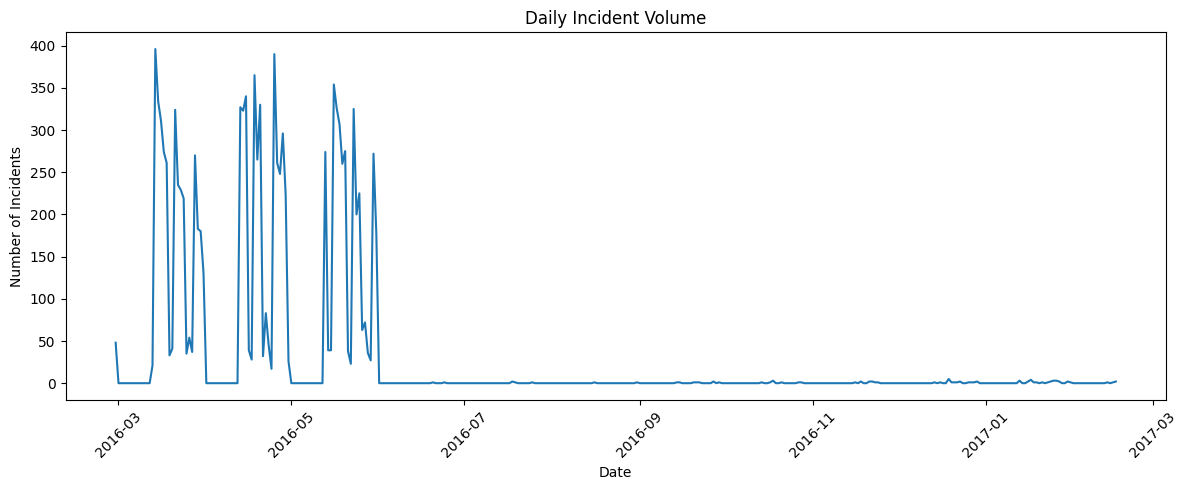

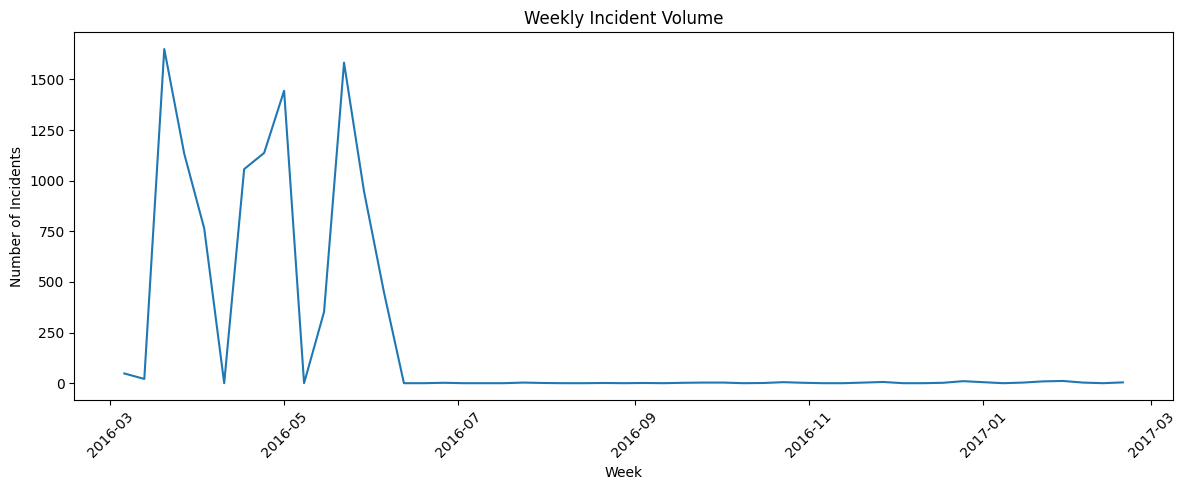

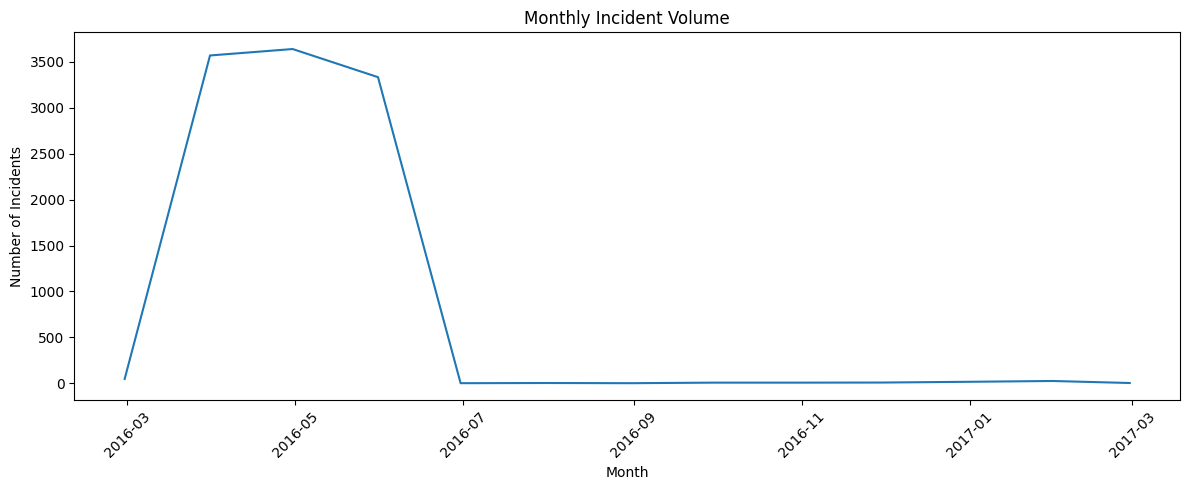

In [191]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(daily_volume['opened_at'], daily_volume['incident_count'])
plt.title('Daily Incident Volume')
plt.xlabel('Date')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(weekly_volume['opened_at'], weekly_volume['incident_count'])
plt.title('Weekly Incident Volume')
plt.xlabel('Week')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.plot(monthly_volume['opened_at'], monthly_volume['incident_count'])
plt.title('Monthly Incident Volume')
plt.xlabel('Month')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [192]:
print(f"Minimum opened_at date: {incident_df['opened_at'].min()}")
print(f"Maximum opened_at date: {incident_df['opened_at'].max()}")

Minimum opened_at date: 2016-02-29 01:16:00
Maximum opened_at date: 2017-02-16 14:17:00


# **USER STORY 2 - Average and median resolution time**

In [193]:
#calculate average+median and group by priority
incident_df.groupby('priority')['resolution_time_hours'].agg(['mean', 'median'])

,mean,median
priority,,
1 - critical,60.390132,24.083333
2 - high,49.392708,12.133333
3 - moderate,45.507600,2.233333
4 - low,30.761023,0.466667


In [194]:
#cleaned look
result = incident_df.groupby('priority')['resolution_time_hours'].agg(['mean', 'median']).reset_index()
print(result)

       priority       mean     median
0  1 - critical  60.390132  24.083333
1      2 - high  49.392708  12.133333
2  3 - moderate  45.507600   2.233333
3       4 - low  30.761023   0.466667


**VISUALIZATIONS**

shows whether higher priority incidents are actually being resolved faster and helps identify any gaps in performance across priority levels.

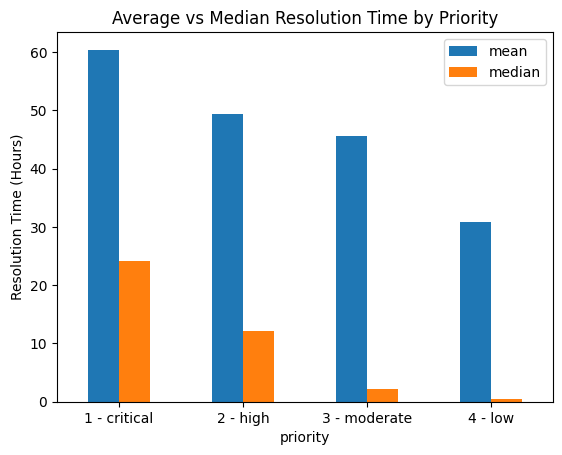

In [195]:
import matplotlib.pyplot as plt

result.plot(x='priority', y=['mean', 'median'], kind='bar')
plt.title('Average vs Median Resolution Time by Priority')
plt.ylabel('Resolution Time (Hours)')
plt.xticks(rotation=0)
plt.show()

limitation on  analysis

One limitation is that resolution time alone doesn’t capture complexity of incidents, and outliers can still affect the average, which is why I included the median

# **USER STORY 3 - SLA adherence rates tracking**

In [196]:
us3_df = incident_df.copy()

us3_df['made_sla'] = us3_df['made_sla'].astype(str).str.strip().str.lower()

sla_map = {
    'true': 'Met SLA',
    'false': 'Breached SLA'
}

us3_df['sla_status'] = us3_df['made_sla'].map(sla_map)
us3_df = us3_df.dropna(subset=['sla_status']).copy()

sla_counts = us3_df['sla_status'].value_counts().reset_index()
sla_counts.columns = ['sla_status', 'incident_count']

met_sla_count = (us3_df['sla_status'] == 'Met SLA').sum()
breached_sla_count = (us3_df['sla_status'] == 'Breached SLA').sum()
total_sla_records = len(us3_df)
sla_compliance_rate = (met_sla_count / total_sla_records) * 100 if total_sla_records > 0 else 0

print('SLA counts:')
print(sla_counts)
print(f'\nTotal SLA-eligible incidents: {total_sla_records}')
print(f'Met SLA: {met_sla_count}')
print(f'Breached SLA: {breached_sla_count}')
print(f'SLA Compliance Rate: {sla_compliance_rate:.2f}%')

SLA counts:
     sla_status  incident_count
0       Met SLA            8253
1  Breached SLA            2413

Total SLA-eligible incidents: 10666
Met SLA: 8253
Breached SLA: 2413
SLA Compliance Rate: 77.38%


In [197]:
us3_df = incident_df.copy()

us3_df['made_sla'] = us3_df['made_sla'].astype(str).str.strip().str.lower()

sla_map = {
    'true': 'Met SLA',
    'false': 'Breached SLA'
}

us3_df['sla_status'] = us3_df['made_sla'].map(sla_map)
us3_df = us3_df.dropna(subset=['sla_status']).copy()

sla_counts = us3_df['sla_status'].value_counts().reset_index()
sla_counts.columns = ['sla_status', 'incident_count']

met_sla_count = (us3_df['sla_status'] == 'Met SLA').sum()
breached_sla_count = (us3_df['sla_status'] == 'Breached SLA').sum()
total_sla_records = len(us3_df)
sla_compliance_rate = (met_sla_count / total_sla_records) * 100 if total_sla_records > 0 else 0

print('SLA counts:')
print(sla_counts)
print(f'\nTotal SLA-eligible incidents: {total_sla_records}')
print(f'Met SLA: {met_sla_count}')
print(f'Breached SLA: {breached_sla_count}')
print(f'SLA Compliance Rate: {sla_compliance_rate:.2f}%')

SLA counts:
     sla_status  incident_count
0       Met SLA            8253
1  Breached SLA            2413

Total SLA-eligible incidents: 10666
Met SLA: 8253
Breached SLA: 2413
SLA Compliance Rate: 77.38%


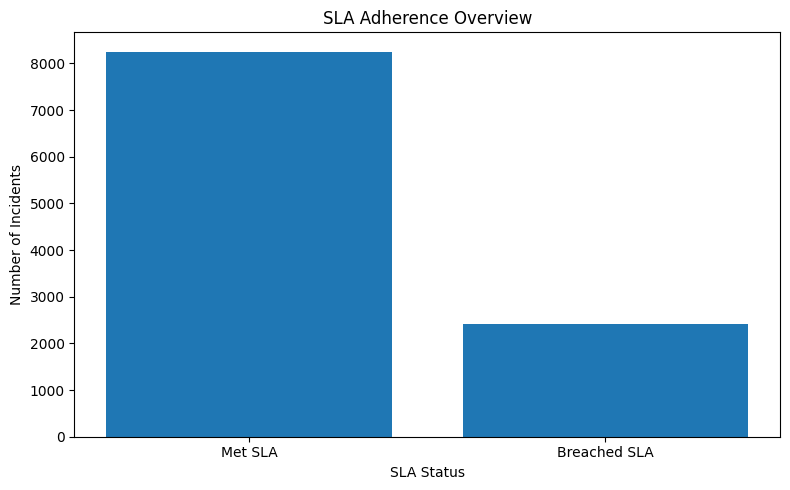

In [198]:
#Graph showing who met/breached SLA
plt.figure(figsize=(8, 5))
plt.bar(sla_counts['sla_status'], sla_counts['incident_count'])
plt.title('SLA Adherence Overview')
plt.xlabel('SLA Status')
plt.ylabel('Number of Incidents')
plt.tight_layout()
plt.show()

sla_violations = us3_df[us3_df['sla_status'] == 'Breached SLA'].copy()
sla_violations.to_csv('sla_violations.csv', index=False)

In [199]:
#Downloadable CSV for incidents which had SLA violations
sla_violations_df = pd.read_csv('sla_violations.csv')
display(sla_violations_df.head())

,number,opened_at,resolved_at,closed_at,priority,urgency,impact,category,assignment_group,reassignment_count,reopen_count,made_sla,resolution_time_hours,sla_status
0,INC0000062,2016-02-29 06:58:00,2016-02-29 15:51:00,2016-03-05 16:00:00,3 - moderate,2 - Medium,2 - Medium,category 53,Group 23,1,0,False,8.883333,Breached SLA
1,INC0000102,2016-02-29 09:06:00,2016-03-17 16:28:00,2016-03-24 18:59:00,3 - moderate,2 - Medium,2 - Medium,category 37,Group 23,4,1,False,415.366667,Breached SLA
2,INC0000147,2016-02-29 10:00:00,2016-03-14 09:49:00,2016-03-19 10:00:00,3 - moderate,2 - Medium,2 - Medium,category 53,Group 25,1,0,False,335.816667,Breached SLA
3,INC0000171,2016-02-29 10:33:00,2016-03-18 13:44:00,2016-03-24 18:59:00,3 - moderate,2 - Medium,2 - Medium,category 24,Group 70,4,0,False,435.183333,Breached SLA
4,INC0000294,2016-02-29 14:06:00,2016-03-14 08:25:00,2016-03-24 18:50:00,3 - moderate,2 - Medium,2 - Medium,category 20,Group 25,1,1,False,330.316667,Breached SLA


   opened_at  total_incidents  met_sla  compliance_rate_pct
0 2016-02-29               48       34            70.833333
1 2016-03-31             3568     2120            59.417040
2 2016-04-30             3638     3127            85.953821
3 2016-05-31             3332     2898            86.974790
4 2016-06-30                2        2           100.000000


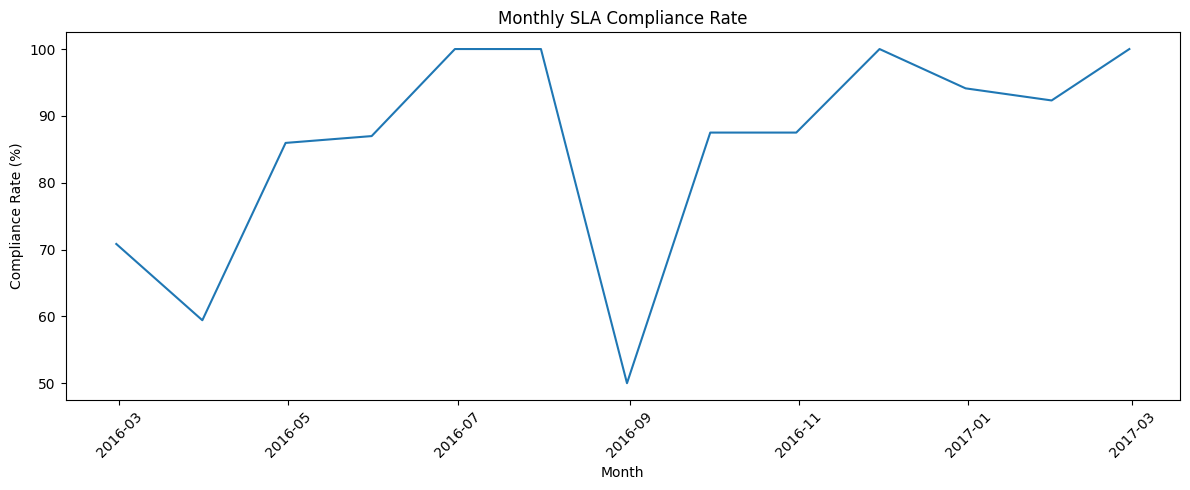

In [200]:
us3_df['opened_at'] = pd.to_datetime(us3_df['opened_at'], errors='coerce')
us3_df = us3_df.dropna(subset=['opened_at']).copy()

monthly_sla = (
    us3_df.assign(met_flag=(us3_df['sla_status'] == 'Met SLA').astype(int))
    .set_index('opened_at')
    .resample('ME')
    .agg(
        total_incidents=('sla_status', 'count'),
        met_sla=('met_flag', 'sum')
    )
    .reset_index()
)

monthly_sla['compliance_rate_pct'] = (
    monthly_sla['met_sla'] / monthly_sla['total_incidents']
) * 100

print(monthly_sla.head())

plt.figure(figsize=(12, 5))
plt.plot(monthly_sla['opened_at'], monthly_sla['compliance_rate_pct'])
plt.title('Monthly SLA Compliance Rate')
plt.xlabel('Month')
plt.ylabel('Compliance Rate (%)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# **USER STORY 4 - Compare resolution time across groups**

Resolution Time (Mean and Median) by Assignment Group:
   assignment_group        mean      median
65          Group 9  338.800000  338.800000
24         Group 35  240.216667  240.216667
14         Group 26  187.647222  213.141667
48         Group 61  166.154167  149.283333
4          Group 15  160.135714  122.433333


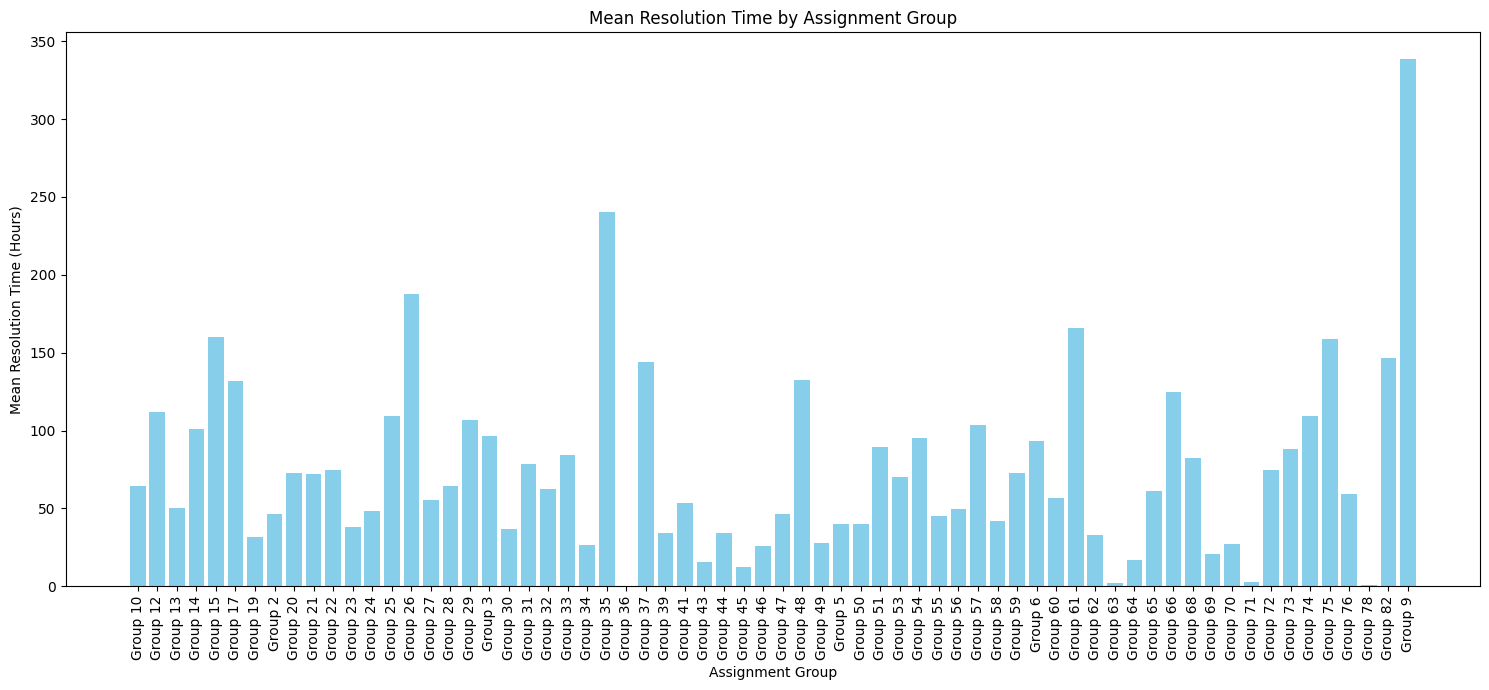

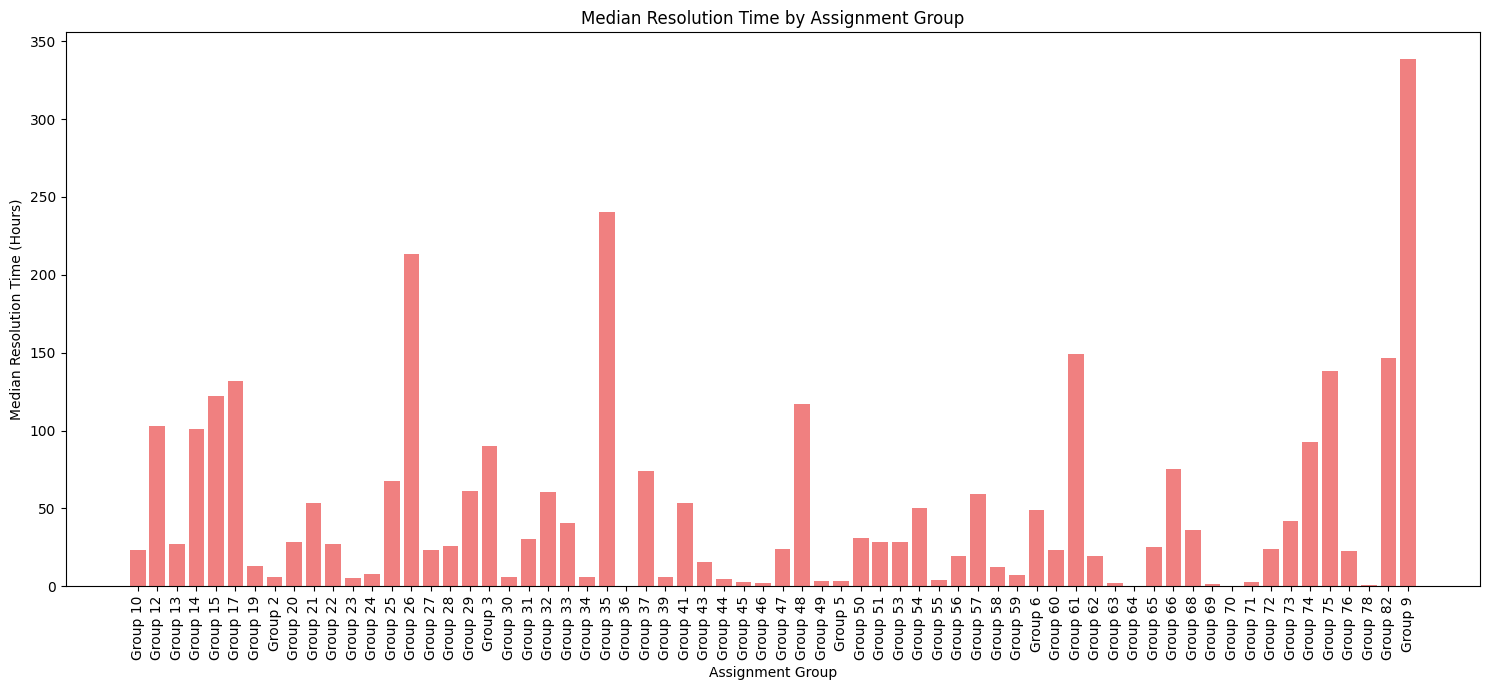

In [201]:
resolution_by_group = incident_df.groupby('assignment_group')['resolution_time_hours'].agg(['mean', 'median']).reset_index()
print("Resolution Time (Mean and Median) by Assignment Group:")
print(resolution_by_group.sort_values(by='mean', ascending=False).head())

# Plotting for mean resolution time
plt.figure(figsize=(15, 7))
plt.bar(resolution_by_group['assignment_group'], resolution_by_group['mean'], color='skyblue')
plt.xlabel('Assignment Group')
plt.ylabel('Mean Resolution Time (Hours)')
plt.title('Mean Resolution Time by Assignment Group')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

# Plotting for median resolution time
plt.figure(figsize=(15, 7))
plt.bar(resolution_by_group['assignment_group'], resolution_by_group['median'], color='lightcoral')
plt.xlabel('Assignment Group')
plt.ylabel('Median Resolution Time (Hours)')
plt.title('Median Resolution Time by Assignment Group')
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [202]:
sla_breaches_by_group = sla_violations.groupby('assignment_group').size().reset_index(name='breach_count')

# Sort by breach_count in descending order
sla_breaches_by_group = sla_breaches_by_group.sort_values(by='breach_count', ascending=False)

display(sla_breaches_by_group.head(5))

,assignment_group,breach_count
52,Group 70,729
13,Group 25,196
27,Group 39,107
12,Group 24,101
8,Group 20,80


A low average or median resolution time for a group does not necessarily indicate optimal performance.Group 70, having one of the lowest median and mean resolution times, represents the highest number of SLA violations. This suggests that while they resolve many incidents quickly, they also frequently breach service level agreements.

# USER STORY 5 - Analyze incident categories by frequency and resolution time

In [203]:
#calculating incident count by category
category_frequency = incident_df['category'].value_counts().reset_index()
category_frequency.columns = ['category', 'incident_count']
print('Incident Categories by Frequency:')
display(category_frequency.head())

Incident Categories by Frequency:


,category,incident_count
0,category 42,1723
1,category 26,1503
2,category 53,1169
3,category 46,1012
4,category 32,627


In [221]:
# Calculate mean and median resolution time for each category
category_resolution_time = incident_df.groupby('category')['resolution_time_hours'].agg(['mean', 'median']).reset_index()
category_resolution_time.columns = ['category', 'mean_resolution_hours', 'median_resolution_hours']
print('\nIncident Categories by Mean Resolution Time (Ascending):')
display(category_resolution_time.sort_values(by='mean_resolution_hours', ascending=True).head())

print('\nIncident Categories by Median Resolution Time (Ascending):')
display(category_resolution_time.sort_values(by='median_resolution_hours', ascending=True).head())


Incident Categories by Mean Resolution Time (Ascending):


,category,mean_resolution_hours,median_resolution_hours
32,category 5,0.208333,0.208333
6,category 2,1.841667,1.841667
15,category 29,12.833333,12.833333
34,category 51,15.651318,0.125000
20,category 35,15.939502,0.216667



Incident Categories by Median Resolution Time (Ascending):


,category,mean_resolution_hours,median_resolution_hours
34,category 51,15.651318,0.125000
32,category 5,0.208333,0.208333
20,category 35,15.939502,0.216667
17,category 31,42.623333,0.283333
18,category 32,24.664567,0.383333


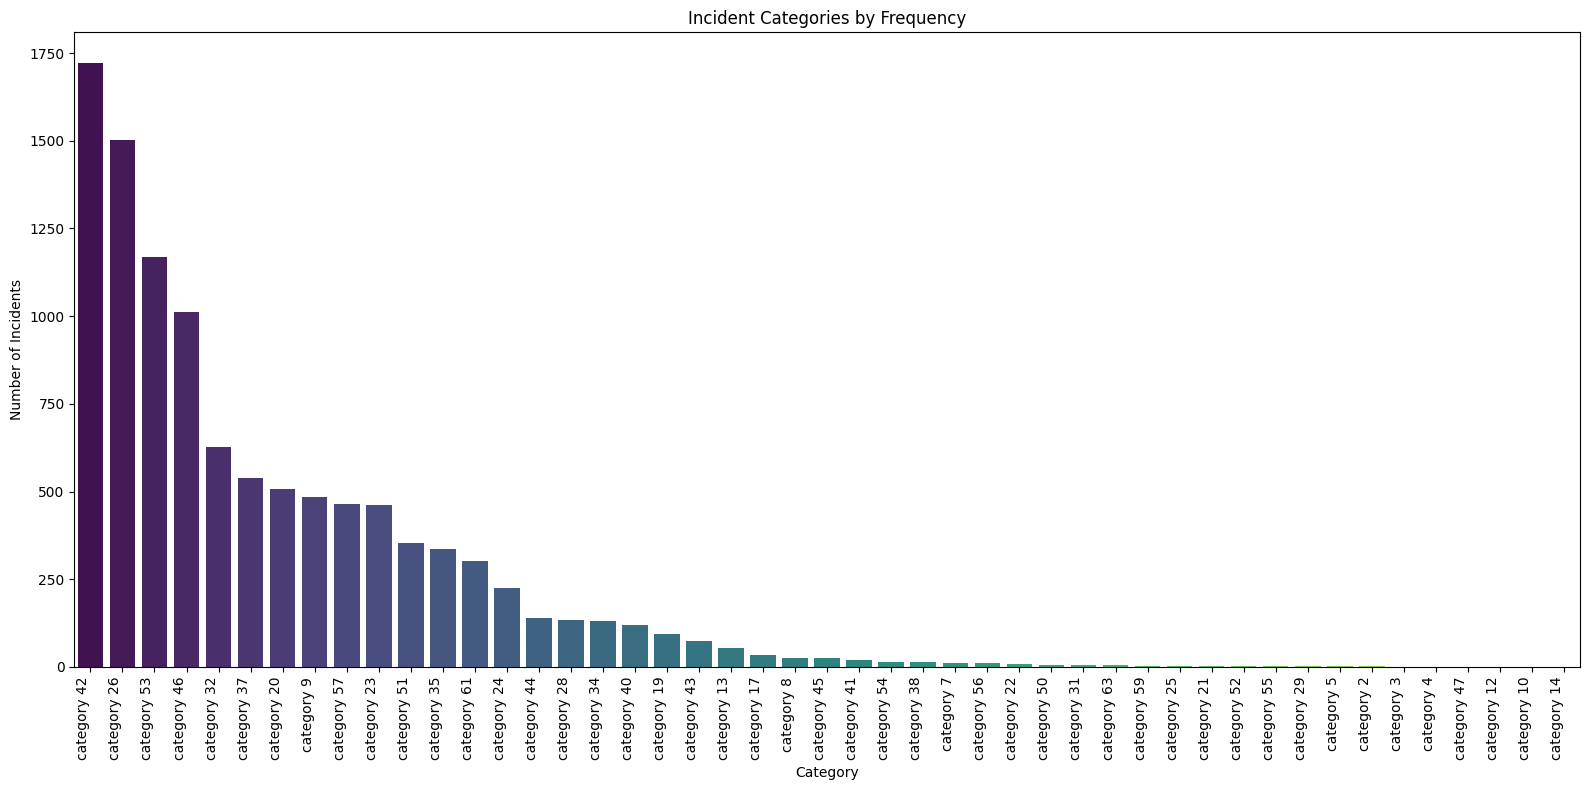

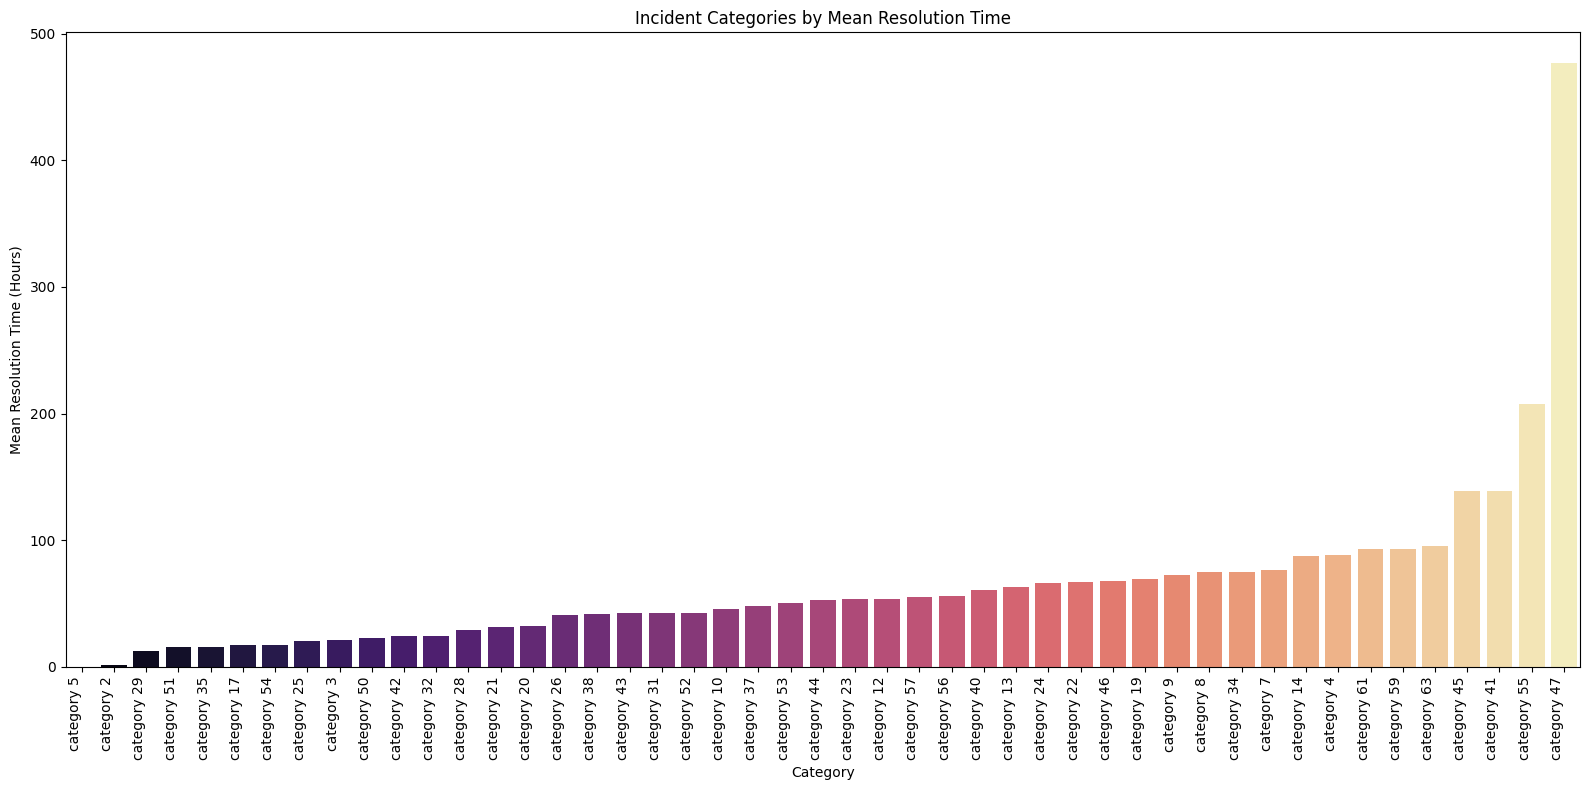

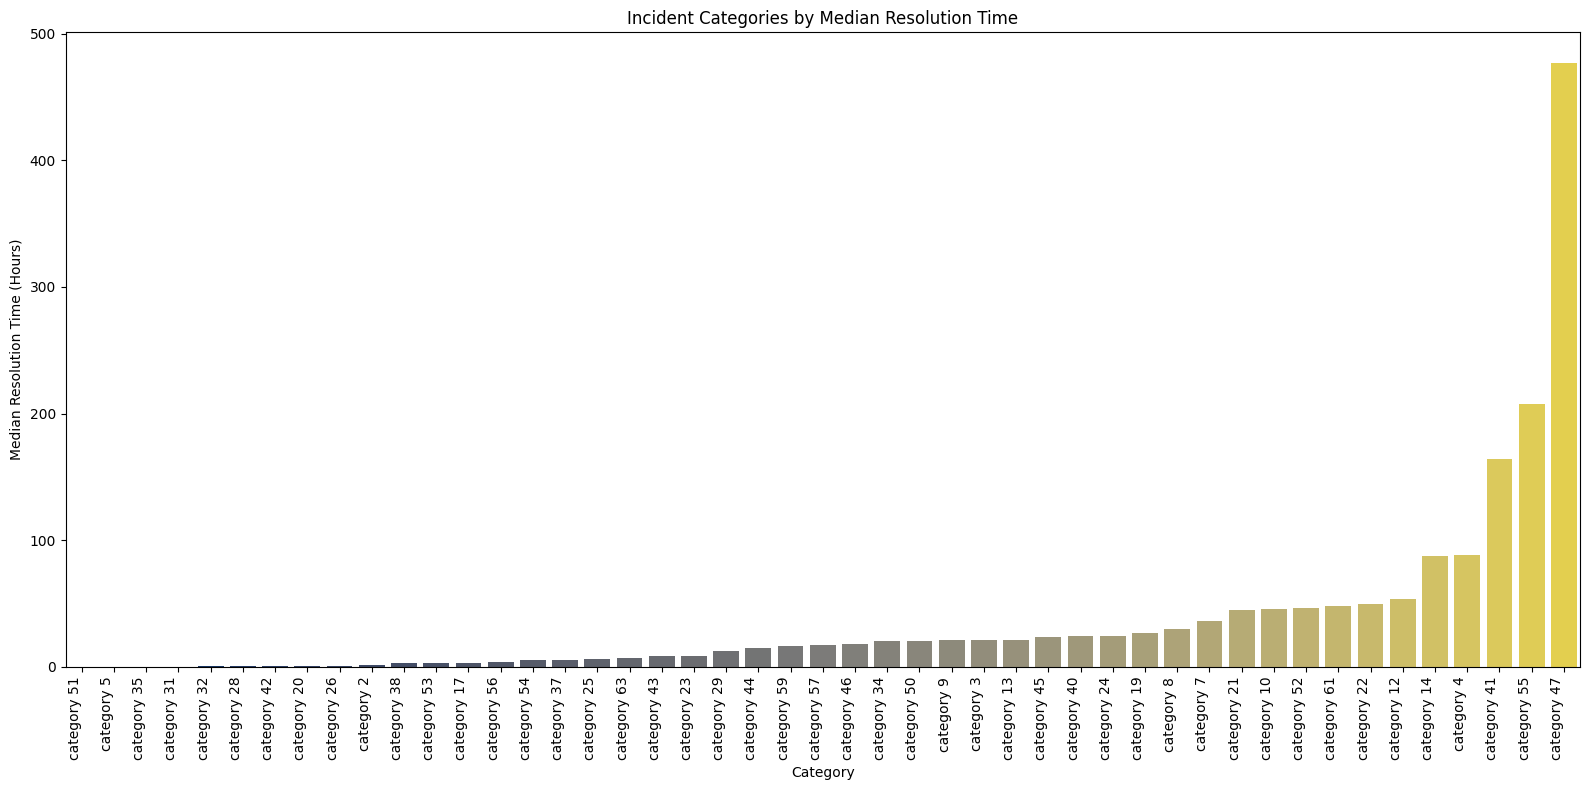

In [205]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plotting Category Frequency
plt.figure(figsize=(16, 8)) # Increased figure size
sns.barplot(x='category', y='incident_count', data=category_frequency, hue='category', palette='viridis', legend=False)
plt.title('Incident Categories by Frequency')
plt.xlabel('Category')
plt.ylabel('Number of Incidents')
plt.xticks(rotation=90, ha='right') # Rotate labels more
plt.tight_layout()
plt.show()

# Plotting Mean Resolution Time by Category
plt.figure(figsize=(16, 8)) # Increased figure size
sns.barplot(x='category', y='mean_resolution_hours', data=category_resolution_time.sort_values(by='mean_resolution_hours'), hue='category', palette='magma', legend=False)
plt.title('Incident Categories by Mean Resolution Time')
plt.xlabel('Category')
plt.ylabel('Mean Resolution Time (Hours)')
plt.xticks(rotation=90, ha='right') # Rotate labels more
plt.tight_layout()
plt.show()

# Plotting Median Resolution Time by Category
plt.figure(figsize=(16, 8)) # Increased figure size
sns.barplot(x='category', y='median_resolution_hours', data=category_resolution_time.sort_values(by='median_resolution_hours'), hue='category', palette='cividis', legend=False)
plt.title('Incident Categories by Median Resolution Time')
plt.xlabel('Category')
plt.ylabel('Median Resolution Time (Hours)')
plt.xticks(rotation=90, ha='right') # Rotate labels more
plt.tight_layout()
plt.show()

A note on resolution times: While some categories, like 'category 33', show very high mean resolution times, it's important to check the data volume. If a category has only one or very few incidents, this high average might be skewed and not representative of its performance.

# **USER STORY 7 - Visualize incident lifecycle stages**

In [206]:
lifecycle_df = incident_df.copy()

# Calculate time from resolved to closed
# Handle cases where incidents might be resolved but not yet closed (NaT in closed_at)
lifecycle_df['time_to_close_hours'] = (
    lifecycle_df['closed_at'] - lifecycle_df['resolved_at']
).dt.total_seconds() / 3600

# Calculate total incident duration (opened to closed)
lifecycle_df['total_lifecycle_hours'] = (
    lifecycle_df['closed_at'] - lifecycle_df['opened_at']
).dt.total_seconds() / 3600

# Display descriptive statistics for these new durations
print('Time to close after resolution (hours):')
display(lifecycle_df['time_to_close_hours'].describe())

print('\nTotal incident lifecycle duration (hours):')
display(lifecycle_df['total_lifecycle_hours'].describe())

# It's important to filter out negative durations or NaNs if they represent invalid data
# We already filtered resolution_time_hours for >=0 earlier
lifecycle_df = lifecycle_df[lifecycle_df['time_to_close_hours'] >= 0].copy()
lifecycle_df = lifecycle_df[lifecycle_df['total_lifecycle_hours'] >= 0].copy()

# Drop NaNs that might result from missing resolved_at or closed_at for duration calculations
lifecycle_df.dropna(subset=['resolution_time_hours', 'time_to_close_hours', 'total_lifecycle_hours'], inplace=True)

Time to close after resolution (hours):


,time_to_close_hours
count,10666.000000
mean,134.393314
std,127.447614
min,0.000000
25%,120.250000
50%,120.516667
75%,120.783333
max,5851.650000



Total incident lifecycle duration (hours):


,total_lifecycle_hours
count,10666.000000
mean,179.706555
std,149.195057
min,0.050000
25%,120.850000
50%,124.441667
75%,198.395833
max,5856.616667


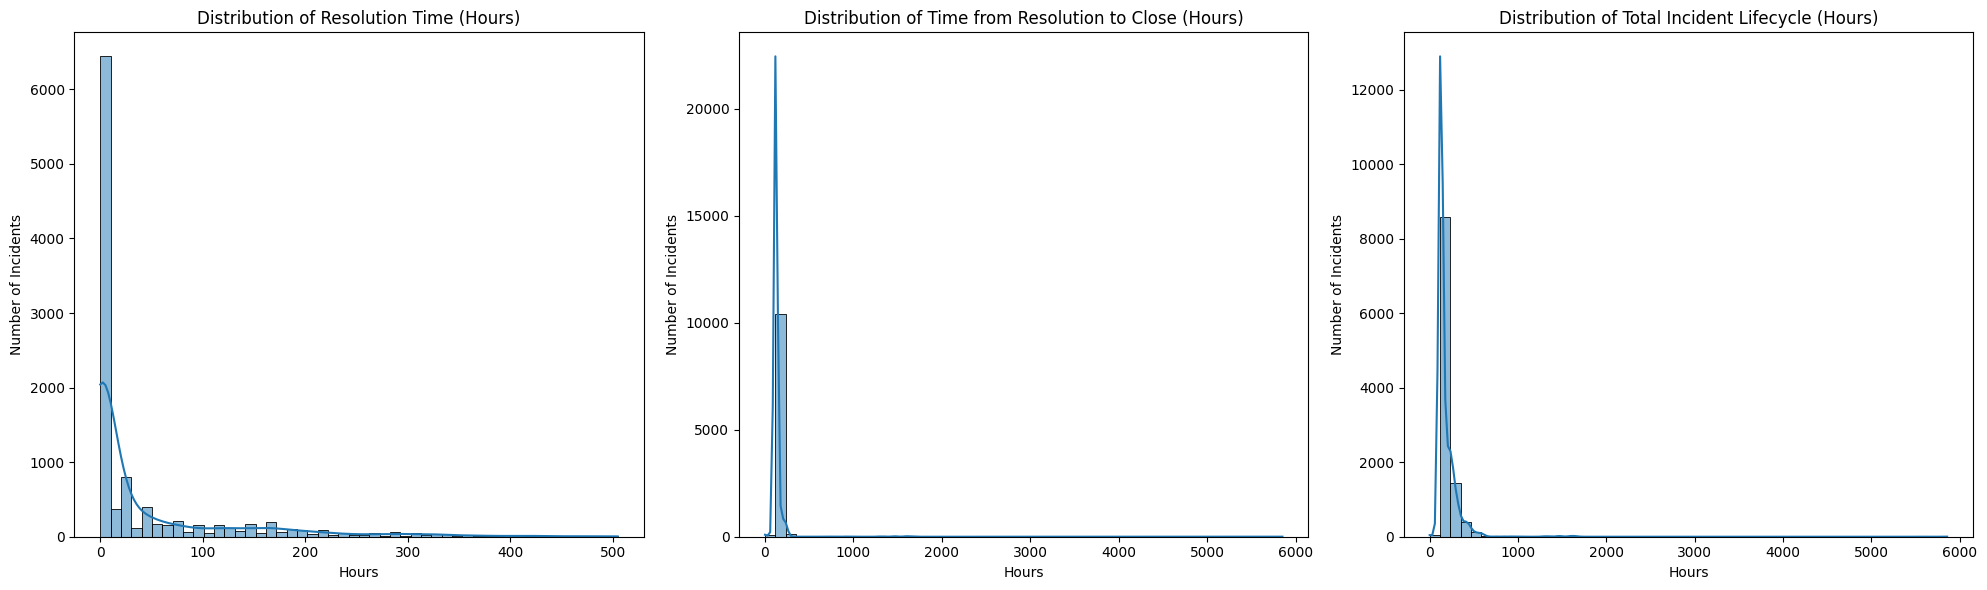

In [207]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

sns.histplot(lifecycle_df['resolution_time_hours'], bins=50, kde=True, ax=axes[0])
axes[0].set_title('Distribution of Resolution Time (Hours)')
axes[0].set_xlabel('Hours')
axes[0].set_ylabel('Number of Incidents')

sns.histplot(lifecycle_df['time_to_close_hours'], bins=50, kde=True, ax=axes[1])
axes[1].set_title('Distribution of Time from Resolution to Close (Hours)')
axes[1].set_xlabel('Hours')
axes[1].set_ylabel('Number of Incidents')

sns.histplot(lifecycle_df['total_lifecycle_hours'], bins=50, kde=True, ax=axes[2])
axes[2].set_title('Distribution of Total Incident Lifecycle (Hours)')
axes[2].set_xlabel('Hours')
axes[2].set_ylabel('Number of Incidents')

plt.tight_layout()
plt.show()

# **USER STORY 8 - Predictive model that estimates incident resolution**

In [208]:
# ------------------------------------------
# User Story 8: Resolution Time Analysis
# ------------------------------------------

analysis_df = incident_df.copy()

# Average resolution time by category
category_analysis = (
    analysis_df.groupby('category')['resolution_time_hours']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Categories by Average Resolution Time:")
print(category_analysis)

# Average resolution time by assignment group
group_analysis = (
    analysis_df.groupby('assignment_group')['resolution_time_hours']
    .mean()
    .sort_values(ascending=False)
    .head(10)
)

print("\nTop 10 Assignment Groups by Average Resolution Time:")
print(group_analysis)

Top 10 Categories by Average Resolution Time:
category
category 47    477.100000
category 55    207.958333
category 41    139.130833
category 45    139.015333
category 63     95.803333
category 59     93.350000
category 61     93.085424
category 4      88.350000
category 14     87.766667
category 7      76.229167
Name: resolution_time_hours, dtype: float64

Top 10 Assignment Groups by Average Resolution Time:
assignment_group
Group 9     338.800000
Group 35    240.216667
Group 26    187.647222
Group 61    166.154167
Group 15    160.135714
Group 75    158.991667
Group 82    146.283333
Group 37    143.876852
Group 48    132.305729
Group 17    131.808333
Name: resolution_time_hours, dtype: float64


# **USER STORY 9 - Recommend actionable process based on models**

In [209]:
# ------------------------------------------
# User Story 9: SLA Prediction Model
# ------------------------------------------

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report

ml_df = incident_df.copy().dropna(subset=[
    'priority', 'urgency', 'impact',
    'category', 'assignment_group',
    'resolution_time_hours', 'made_sla'
])

# Encode categorical columns
for col in ['priority', 'urgency', 'impact', 'category', 'assignment_group']:
    encoder = LabelEncoder()
    ml_df[col] = encoder.fit_transform(ml_df[col].astype(str))

# Convert SLA field to binary
ml_df['made_sla'] = (
    ml_df['made_sla']
    .astype(str)
    .str.strip()
    .str.lower()
    .map({'true': 1, 'false': 0, '1': 1, '0': 0, 'yes': 1, 'no': 0})
)

ml_df = ml_df.dropna(subset=['made_sla'])

X = ml_df[['priority', 'urgency', 'impact', 'category', 'assignment_group', 'resolution_time_hours']]
y = ml_df['made_sla']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(random_state=42)
model.fit(X_train, y_train)

predictions = model.predict(X_test)

print("SLA Prediction Accuracy:", accuracy_score(y_test, predictions))
print("\nClassification Report:")
print(classification_report(y_test, predictions))

SLA Prediction Accuracy: 0.909437559580553

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.75      0.79       477
           1       0.93      0.96      0.94      1621

    accuracy                           0.91      2098
   macro avg       0.88      0.85      0.87      2098
weighted avg       0.91      0.91      0.91      2098



# **USER STORY 10 - Downloadable reports of key dashboards**

In [210]:
from matplotlib.backends.backend_pdf import PdfPages
from io import BytesIO
import os

try:
    from pptx import Presentation
    from pptx.util import Inches
    PPTX_AVAILABLE = True
except ImportError:
    PPTX_AVAILABLE = False
    print("python-pptx is not installed. PDF export will still work.")

python-pptx is not installed. PDF export will still work.


In [211]:
def load_clean_incident_dataset(path='clean_incident_data.csv'):
    """Load the cleaned incident dataset from memory or disk and standardize fields."""
    if 'incident_df' in globals():
        df = incident_df.copy()
    elif os.path.exists(path):
        df = pd.read_csv(path)
    else:
        raise FileNotFoundError(
            "Cleaned incident data was not found. Run the User Story 6 cells first "
            "or make sure clean_incident_data.csv exists in the notebook folder."
        )

    date_columns = ['opened_at', 'resolved_at', 'closed_at']
    for col in date_columns:
        if col in df.columns:
            df[col] = pd.to_datetime(df[col], errors='coerce')

    for col in ['priority', 'category', 'assignment_group']:
        if col in df.columns:
            df[col] = df[col].astype(str).str.strip().str.lower()

    if 'made_sla' in df.columns:
        df['made_sla'] = df['made_sla'].astype(str).str.strip().str.lower()

    return df


def filter_dashboard_data(df, priority='all', category='all', start_date=None, end_date=None):
    """Apply dashboard filters for time period, priority, and category."""
    filtered = df.copy()

    if priority != 'all' and 'priority' in filtered.columns:
        filtered = filtered[filtered['priority'] == priority]

    if category != 'all' and 'category' in filtered.columns:
        filtered = filtered[filtered['category'] == category]

    if start_date is not None and 'opened_at' in filtered.columns:
        filtered = filtered[filtered['opened_at'] >= pd.to_datetime(start_date)]

    if end_date is not None and 'opened_at' in filtered.columns:
        filtered = filtered[filtered['opened_at'] <= pd.to_datetime(end_date)]

    return filtered.copy()


def build_dashboard_summaries(df, time_frequency='M'):
    """Create summary tables used by the export report and interactive dashboard."""
    if df.empty:
        return {
            'volume': pd.DataFrame(columns=['period', 'incident_count']),
            'resolution': pd.DataFrame(columns=['priority', 'mean', 'median']),
            'sla': pd.DataFrame(columns=['sla_status', 'incident_count']),
            'category': pd.DataFrame(columns=['category', 'incident_count', 'avg_resolution_hours']),
            'monthly_sla': pd.DataFrame(columns=['opened_at', 'total_incidents', 'met_sla', 'compliance_rate_pct']),
            'resolution_by_group': pd.DataFrame(columns=['assignment_group', 'mean', 'median']),
            'sla_breaches_by_group': pd.DataFrame(columns=['assignment_group', 'breach_count']),
            'category_resolution_time': pd.DataFrame(columns=['category', 'mean_resolution_hours', 'median_resolution_hours'])
        }

    volume = (
        df.dropna(subset=['opened_at'])
        .set_index('opened_at')
        .resample(time_frequency)
        .size()
        .reset_index(name='incident_count')
        .rename(columns={'opened_at': 'period'})
    )

    resolution = (
        df.dropna(subset=['priority', 'resolution_time_hours'])
        .groupby('priority')['resolution_time_hours']
        .agg(['mean', 'median'])
        .reset_index()
        .sort_values('mean', ascending=False)
    )

    sla_map = {
        'true': 'Met SLA',
        'false': 'Breached SLA',
        '1': 'Met SLA',
        '0': 'Breached SLA',
        'yes': 'Met SLA',
        'no': 'Breached SLA'
    }

    working_sla = df.copy()
    if 'made_sla' in working_sla.columns:
        working_sla['sla_status'] = working_sla['made_sla'].map(sla_map)
        sla = (
            working_sla.dropna(subset=['sla_status'])
            ['sla_status']
            .value_counts()
            .reset_index()
        )
        sla.columns = ['sla_status', 'incident_count']
    else:
        sla = pd.DataFrame(columns=['sla_status', 'incident_count'])

    category = (
        df.dropna(subset=['category', 'resolution_time_hours'])
        .groupby('category')
        .agg(
            incident_count=('number', 'count'),
            avg_resolution_hours=('resolution_time_hours', 'mean')
        )
        .reset_index()
        .sort_values(['incident_count', 'avg_resolution_hours'], ascending=[False, False])
        .head(10)
    )

    # New: Monthly SLA Compliance Rate
    if 'opened_at' in df.columns and 'sla_status' in working_sla.columns and not working_sla['sla_status'].isnull().all():
        monthly_sla = (
            working_sla.assign(met_flag=(working_sla['sla_status'] == 'Met SLA').astype(int))
            .set_index('opened_at')
            .resample(time_frequency)
            .agg(
                total_incidents=('sla_status', 'count'),
                met_sla=('met_flag', 'sum')
            )
            .reset_index()
        )
        monthly_sla['compliance_rate_pct'] = (
            monthly_sla['met_sla'] / monthly_sla['total_incidents']
        ) * 100
    else:
        monthly_sla = pd.DataFrame(columns=['opened_at', 'total_incidents', 'met_sla', 'compliance_rate_pct'])

    # New: Resolution Time by Assignment Group
    if 'assignment_group' in df.columns and 'resolution_time_hours' in df.columns and not df['resolution_time_hours'].isnull().all():
        resolution_by_group = (
            df.dropna(subset=['assignment_group', 'resolution_time_hours'])
            .groupby('assignment_group')['resolution_time_hours']
            .agg(['mean', 'median'])
            .reset_index()
        )
    else:
        resolution_by_group = pd.DataFrame(columns=['assignment_group', 'mean', 'median'])

    # New: SLA Breaches by Assignment Group
    if 'assignment_group' in df.columns and 'sla_status' in working_sla.columns and not working_sla['sla_status'].isnull().all():
        sla_violations = working_sla[working_sla['sla_status'] == 'Breached SLA'].copy()
        sla_breaches_by_group = (
            sla_violations.groupby('assignment_group').size().reset_index(name='breach_count')
        )
        sla_breaches_by_group = sla_breaches_by_group.sort_values(by='breach_count', ascending=False)
    else:
        sla_breaches_by_group = pd.DataFrame(columns=['assignment_group', 'breach_count'])

    # New: Category Resolution Time
    if 'category' in df.columns and 'resolution_time_hours' in df.columns and not df['resolution_time_hours'].isnull().all():
        category_resolution_time = (
            df.dropna(subset=['category', 'resolution_time_hours'])
            .groupby('category')['resolution_time_hours']
            .agg(['mean', 'median'])
            .reset_index()
        )
        category_resolution_time.columns = ['category', 'mean_resolution_hours', 'median_resolution_hours']
    else:
        category_resolution_time = pd.DataFrame(columns=['category', 'mean_resolution_hours', 'median_resolution_hours'])

    return {
        'volume': volume,
        'resolution': resolution,
        'sla': sla,
        'category': category,
        'monthly_sla': monthly_sla,
        'resolution_by_group': resolution_by_group,
        'sla_breaches_by_group': sla_breaches_by_group,
        'category_resolution_time': category_resolution_time
    }

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns # Added for new plots
from matplotlib.backends.backend_pdf import PdfPages
from io import BytesIO

def create_dashboard_report_figures(df, time_frequency='ME'):
    """Generate the key charts that will be exported to PDF/PPTX reports."""
    summaries = build_dashboard_summaries(df, time_frequency=time_frequency)
    figures = []

    # Figure 1: Incident volume over time
    fig1, ax1 = plt.subplots(figsize=(11, 4.5))
    if not summaries['volume'].empty:
        ax1.plot(summaries['volume']['period'], summaries['volume']['incident_count'])
        ax1.set_title('Incident Volume Over Time')
        ax1.set_xlabel('Period')
        ax1.set_ylabel('Incident Count')
        ax1.tick_params(axis='x', rotation=45)
    else:
        ax1.text(0.5, 0.5, 'No data available for the selected filters', ha='center', va='center')
        ax1.set_title('Incident Volume Over Time')
    fig1.tight_layout()
    figures.append(('Incident Volume Over Time', fig1))

    # Figure 2: Resolution time by priority
    fig2, ax2 = plt.subplots(figsize=(10, 4.5))
    if not summaries['resolution'].empty:
        resolution = summaries['resolution'].set_index('priority')[['mean', 'median']]
        resolution.plot(kind='bar', ax=ax2)
        ax2.set_title('Average and Median Resolution Time by Priority')
        ax2.set_xlabel('Priority')
        ax2.set_ylabel('Resolution Time (Hours)')
        ax2.tick_params(axis='x', rotation=0)
    else:
        ax2.text(0.5, 0.5, 'No priority-based resolution data available', ha='center', va='center')
        ax2.set_title('Average and Median Resolution Time by Priority')
    fig2.tight_layout()
    figures.append(('Resolution Time by Priority', fig2))

    # Figure 3: SLA status overview
    fig3, ax3 = plt.subplots(figsize=(8, 4.5))
    if not summaries['sla'].empty:
        ax3.bar(summaries['sla']['sla_status'], summaries['sla']['incident_count'])
        ax3.set_title('SLA Adherence Overview')
        ax3.set_xlabel('SLA Status')
        ax3.set_ylabel('Incident Count')
    else:
        ax3.text(0.5, 0.5, 'No SLA data available', ha='center', va='center')
        ax3.set_title('SLA Adherence Overview')
    fig3.tight_layout()
    figures.append(('SLA Adherence Overview', fig3))

    # Figure 4: Top categories
    fig4, ax4 = plt.subplots(figsize=(11, 5))
    if not summaries['category'].empty:
        chart_data = summaries['category'].sort_values('incident_count', ascending=True)
        ax4.barh(chart_data['category'], chart_data['incident_count'])
        ax4.set_title('Top Incident Categories by Frequency')
        ax4.set_xlabel('Incident Count')
        ax4.set_ylabel('Category')
    else:
        ax4.text(0.5, 0.5, 'No category data available', ha='center', va='center')
        ax4.set_title('Top Incident Categories by Frequency')
    fig4.tight_layout()
    figures.append(('Top Incident Categories', fig4))

    # Figure 5: Monthly SLA Compliance Rate (NEW)
    fig5, ax5 = plt.subplots(figsize=(11, 4.5))
    if not summaries['monthly_sla'].empty:
        ax5.plot(summaries['monthly_sla']['opened_at'], summaries['monthly_sla']['compliance_rate_pct'])
        ax5.set_title('Monthly SLA Compliance Rate')
        ax5.set_xlabel('Month')
        ax5.set_ylabel('Compliance Rate (%)')
        ax5.tick_params(axis='x', rotation=45)
    else:
        ax5.text(0.5, 0.5, 'No monthly SLA data available', ha='center', va='center')
        ax5.set_title('Monthly SLA Compliance Rate')
    fig5.tight_layout()
    figures.append(('Monthly SLA Compliance Rate', fig5))

    # Figure 6: Mean Resolution Time by Assignment Group (NEW)
    fig6, ax6 = plt.subplots(figsize=(15, 7))
    if not summaries['resolution_by_group'].empty:
        chart_data = summaries['resolution_by_group'].sort_values(by='mean', ascending=False).head(15)
        ax6.bar(chart_data['assignment_group'], chart_data['mean'], color='skyblue')
        ax6.set_title('Mean Resolution Time by Assignment Group (Top 15)')
        ax6.set_xlabel('Assignment Group')
        ax6.set_ylabel('Mean Resolution Time (Hours)')
        ax6.tick_params(axis='x', rotation=90)
    else:
        ax6.text(0.5, 0.5, 'No resolution time by group data available', ha='center', va='center')
        ax6.set_title('Mean Resolution Time by Assignment Group')
    fig6.tight_layout()
    figures.append(('Mean Resolution Time by Assignment Group', fig6))

    # Figure 7: Median Resolution Time by Assignment Group (NEW)
    fig7, ax7 = plt.subplots(figsize=(15, 7))
    if not summaries['resolution_by_group'].empty:
        chart_data = summaries['resolution_by_group'].sort_values(by='median', ascending=False).head(15)
        ax7.bar(chart_data['assignment_group'], chart_data['median'], color='lightcoral')
        ax7.set_title('Median Resolution Time by Assignment Group (Top 15)')
        ax7.set_xlabel('Assignment Group')
        ax7.set_ylabel('Median Resolution Time (Hours)')
        ax7.tick_params(axis='x', rotation=90)
    else:
        ax7.text(0.5, 0.5, 'No resolution time by group data available', ha='center', va='center')
        ax7.set_title('Median Resolution Time by Assignment Group')
    fig7.tight_layout()
    figures.append(('Median Resolution Time by Assignment Group', fig7))

    # Figure 8: Mean Resolution Time by Category (NEW)
    fig8, ax8 = plt.subplots(figsize=(16, 8))
    if not summaries['category_resolution_time'].empty:
        chart_data = summaries['category_resolution_time'].sort_values(by='mean_resolution_hours', ascending=False).head(15)
        sns.barplot(x='category', y='mean_resolution_hours', data=chart_data, ax=ax8, palette='magma', legend=False)
        ax8.set_title('Incident Categories by Mean Resolution Time (Top 15)')
        ax8.set_xlabel('Category')
        ax8.set_ylabel('Mean Resolution Time (Hours)')
        ax8.tick_params(axis='x', rotation=90) # Removed ha='right'
    else:
        ax8.text(0.5, 0.5, 'No category mean resolution data available', ha='center', va='center')
        ax8.set_title('Incident Categories by Mean Resolution Time')
    fig8.tight_layout()
    figures.append(('Incident Categories by Mean Resolution Time', fig8))

    # Figure 9: Median Resolution Time by Category (NEW)
    fig9, ax9 = plt.subplots(figsize=(16, 8))
    if not summaries['category_resolution_time'].empty:
        chart_data = summaries['category_resolution_time'].sort_values(by='median_resolution_hours', ascending=False).head(15)
        sns.barplot(x='category', y='median_resolution_hours', data=chart_data, ax=ax9, palette='cividis', legend=False)
        ax9.set_title('Incident Categories by Median Resolution Time (Top 15)')
        ax9.set_xlabel('Category')
        ax9.set_ylabel('Median Resolution Time (Hours)')
        ax9.tick_params(axis='x', rotation=90) # Removed ha='right'
    else:
        ax9.text(0.5, 0.5, 'No category median resolution data available', ha='center', va='center')
        ax9.set_title('Incident Categories by Median Resolution Time')
    fig9.tight_layout()
    figures.append(('Incident Categories by Median Resolution Time', fig9))

    # Lifecycle Stages - re-calculate lifecycle_df here (NEW)
    lifecycle_df = df.copy()
    lifecycle_df['time_to_close_hours'] = (lifecycle_df['closed_at'] - lifecycle_df['resolved_at']).dt.total_seconds() / 3600
    lifecycle_df['total_lifecycle_hours'] = (lifecycle_df['closed_at'] - lifecycle_df['opened_at']).dt.total_seconds() / 3600
    lifecycle_df = lifecycle_df[lifecycle_df['resolution_time_hours'] >= 0].copy() if 'resolution_time_hours' in lifecycle_df.columns else lifecycle_df # Ensure resolution_time_hours exists
    lifecycle_df = lifecycle_df[lifecycle_df['time_to_close_hours'] >= 0].copy()
    lifecycle_df = lifecycle_df[lifecycle_df['total_lifecycle_hours'] >= 0].copy()
    lifecycle_df.dropna(subset=['resolution_time_hours', 'time_to_close_hours', 'total_lifecycle_hours'], inplace=True)

    if not lifecycle_df.empty:
        # Figure 10: Distribution of Resolution Time (Hours)
        fig10, ax10 = plt.subplots(figsize=(10, 6))
        sns.histplot(lifecycle_df['resolution_time_hours'], bins=50, kde=True, ax=ax10)
        ax10.set_title('Distribution of Resolution Time (Hours)')
        ax10.set_xlabel('Hours')
        ax10.set_ylabel('Number of Incidents')
        fig10.tight_layout()
        figures.append(('Distribution of Resolution Time (Hours)', fig10))

        # Figure 11: Distribution of Time from Resolution to Close (Hours)
        fig11, ax11 = plt.subplots(figsize=(10, 6))
        sns.histplot(lifecycle_df['time_to_close_hours'], bins=50, kde=True, ax=ax11)
        ax11.set_title('Distribution of Time from Resolution to Close (Hours)')
        ax11.set_xlabel('Hours')
        ax11.set_ylabel('Number of Incidents')
        fig11.tight_layout()
        figures.append(('Distribution of Time from Resolution to Close (Hours)', fig11))

        # Figure 12: Distribution of Total Incident Lifecycle (Hours)
        fig12, ax12 = plt.subplots(figsize=(10, 6))
        sns.histplot(lifecycle_df['total_lifecycle_hours'], bins=50, kde=True, ax=ax12)
        ax12.set_title('Distribution of Total Incident Lifecycle (Hours)')
        ax12.set_xlabel('Hours')
        ax12.set_ylabel('Number of Incidents')
        fig12.tight_layout()
        figures.append(('Distribution of Total Incident Lifecycle (Hours)', fig12))

    return summaries, figures


def export_dashboard_report_pdf(df, output_path='executive_dashboard_report.pdf', time_frequency='ME'):
    """Export key dashboard charts and summary tables to a PDF report."""
    summaries, figures = create_dashboard_report_figures(df, time_frequency=time_frequency)

    with PdfPages(output_path) as pdf:
        # Cover page
        cover_fig, cover_ax = plt.subplots(figsize=(11, 8.5))
        cover_ax.axis('off')
        cover_lines = [
            'AI/ML Incident Response Optimization',
            'Executive Dashboard Report',
            '',
            f'Total incidents in report: {len(df):,}',
            f'Report generated from cleaned incident dataset',
            '',
            'Included sections:',
            '- Incident volume trend',
            '- Resolution time by priority',
            '- Monthly SLA compliance rate',
            '- Resolution time by assignment group',
            '- Resolution time by category',
            '- SLA adherence overview',
            '- Top categories by frequency',
            '- Incident lifecycle stage distributions'
        ]
        cover_ax.text(0.05, 0.95, '\n'.join(cover_lines), va='top', fontsize=14)
        pdf.savefig(cover_fig, bbox_inches='tight')
        plt.close(cover_fig)

        for _, fig in figures:
            pdf.savefig(fig, bbox_inches='tight')

        summary_fig, summary_ax = plt.subplots(figsize=(11, 8.5))
        summary_ax.axis('off')

        top_resolution = summaries['resolution'].head(10).round(2)
        top_category = summaries['category'].head(10).round(2)

        summary_text = [
            'Summary Tables',
            '',
            'Resolution Time by Priority',
            top_resolution.to_string(index=False) if not top_resolution.empty else 'No resolution summary available.',
            '',
            'Top Categories',
            top_category.to_string(index=False) if not top_category.empty else 'No category summary available.',
            '',
            'Top Assignment Groups by Mean Resolution Time (Hours)',
            summaries['resolution_by_group'].sort_values(by='mean', ascending=False).head(10).round(2).to_string(index=False) if not summaries['resolution_by_group'].empty else 'No group resolution summary available.',
            '',
            'SLA Breaches by Assignment Group',
            summaries['sla_breaches_by_group'].head(10).round(0).to_string(index=False) if not summaries['sla_breaches_by_group'].empty else 'No SLA breaches by group summary available.'
        ]
        summary_ax.text(0.01, 0.99, '\n'.join(summary_text), va='top', family='monospace')
        pdf.savefig(summary_fig, bbox_inches='tight')
        plt.close(summary_fig)

    for _, fig in figures:
        plt.close(fig)

    print(f'PDF report saved to: {output_path}')
    return output_path


def export_dashboard_report_pptx(df, output_path='executive_dashboard_report.pptx', time_frequency='ME'):
    """Export key dashboard charts to a PowerPoint presentation."""
    if not PPTX_AVAILABLE:
        raise ImportError(
            "python-pptx is not installed in this environment. Install it to export PowerPoint reports."
        )

    summaries, figures = create_dashboard_report_figures(df, time_frequency=time_frequency)
    prs = Presentation()

    title_slide = prs.slides.add_slide(prs.slide_layouts[0])
    title_slide.shapes.title.text = 'Executive Dashboard Report'
    title_slide.placeholders[1].text = (
        'AI/ML Incident Response Optimization\n'
        f'Total incidents in report: {len(df):,}'
    )

    summary_slide = prs.slides.add_slide(prs.slide_layouts[1])
    summary_slide.shapes.title.text = 'Report Summary'
    summary_text = summary_slide.placeholders[1].text_frame
    summary_text.text = 'This presentation includes:'
    for line in [
        'Incident volume trend',
        'Resolution time by priority',
        'Monthly SLA compliance rate',
        'Resolution time by assignment group',
        'Resolution time by category',
        'SLA adherence overview',
        'Top categories by incident count',
        'Incident lifecycle stage distributions'
    ]:
        p = summary_text.add_paragraph()
        p.text = line

    for title, fig in figures:
        slide = prs.slides.add_slide(prs.slide_layouts[5])
        slide.shapes.title.text = title

        image_stream = BytesIO()
        fig.savefig(image_stream, format='png', bbox_inches='tight')
        image_stream.seek(0)
        slide.shapes.add_picture(image_stream, Inches(0.6), Inches(1.3), width=Inches(8.5))

    prs.save(output_path)

    for _, fig in figures:
        plt.close(fig)

    print(f'PowerPoint report saved to: {output_path}')
    return output_path

In [213]:
# Example: export a leadership-ready PDF and PowerPoint report
report_df = load_clean_incident_dataset()

# Optional filter example for executive summaries:
# report_df = filter_dashboard_data(
#     report_df,
#     priority='all',
#     category='all',
#     start_date='2024-01-01',
#     end_date='2024-12-31'
# )

pdf_report_path = export_dashboard_report_pdf(report_df, output_path='executive_dashboard_report.pdf', time_frequency='ME')
print('Created:', pdf_report_path)

if PPTX_AVAILABLE:
    pptx_report_path = export_dashboard_report_pptx(report_df, output_path='executive_dashboard_report.pptx', time_frequency='ME')
    print('Created:', pptx_report_path)
else:
    print('Skipping PowerPoint export because python-pptx is unavailable in this environment.')

/tmp/ipykernel_1438/2035239825.py:115: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='mean_resolution_hours', data=chart_data, ax=ax8, palette='magma', legend=False)
/tmp/ipykernel_1438/2035239825.py:130: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='category', y='median_resolution_hours', data=chart_data, ax=ax9, palette='cividis', legend=False)


PDF report saved to: executive_dashboard_report.pdf
Created: executive_dashboard_report.pdf
Skipping PowerPoint export because python-pptx is unavailable in this environment.


# USER STORY 11 - Filter dashboards by time period, priority, and category in order to conduct customized analysis.

In [214]:
try:
    import ipywidgets as widgets
    WIDGETS_AVAILABLE = True
except ImportError:
    WIDGETS_AVAILABLE = False
    print("ipywidgets is not installed. The interactive filter dashboard will not render.")

from IPython.display import display, clear_output


In [215]:
import matplotlib.pyplot as plt
import seaborn as sns

def render_filtered_dashboard(priority='all', category='all', start_date=None, end_date=None, time_frequency='ME'):
    """Render dashboard outputs after applying the selected filters."""
    df = load_clean_incident_dataset()
    filtered_df = filter_dashboard_data(
        df,
        priority=priority,
        category=category,
        start_date=start_date,
        end_date=end_date
    )

    print(f'Filtered incident count: {len(filtered_df):,}')

    if filtered_df.empty:
        print('No incidents match the selected filters.')
        return filtered_df

    summaries = build_dashboard_summaries(filtered_df, time_frequency=time_frequency)

    # Plot 1: Incident volume over time
    plt.figure(figsize=(11, 4.5))
    plt.plot(summaries['volume']['period'], summaries['volume']['incident_count'])
    plt.title('Filtered Incident Volume Over Time')
    plt.xlabel('Period')
    plt.ylabel('Incident Count')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

    # Plot 2: Resolution time by priority
    if not summaries['resolution'].empty:
        summaries['resolution'].set_index('priority')[['mean', 'median']].plot(
            kind='bar',
            figsize=(10, 4.5)
        )
        plt.title('Filtered Resolution Time by Priority')
        plt.xlabel('Priority')
        plt.ylabel('Resolution Time (Hours)')
        plt.xticks(rotation=0)
        plt.tight_layout()
        plt.show()

    # Plot 3: SLA adherence overview
    if not summaries['sla'].empty:
        plt.figure(figsize=(8, 4.5))
        plt.bar(summaries['sla']['sla_status'], summaries['sla']['incident_count'])
        plt.title('Filtered SLA Adherence Overview')
        plt.xlabel('SLA Status')
        plt.ylabel('Incident Count')
        plt.tight_layout()
        plt.show()

    # Plot 4: Top Incident Categories by Frequency (replacing table display)
    if not summaries['category'].empty:
        plt.figure(figsize=(11, 5))
        chart_data = summaries['category'].sort_values('incident_count', ascending=True)
        plt.barh(chart_data['category'], chart_data['incident_count'])
        plt.title('Filtered Top Incident Categories by Frequency')
        plt.xlabel('Incident Count')
        plt.ylabel('Category')
        plt.tight_layout()
        plt.show()

    # Plot 5: Monthly SLA Compliance Rate
    if not summaries['monthly_sla'].empty and not summaries['monthly_sla']['compliance_rate_pct'].isnull().all():
        plt.figure(figsize=(11, 4.5))
        plt.plot(summaries['monthly_sla']['opened_at'], summaries['monthly_sla']['compliance_rate_pct'])
        plt.title('Filtered Monthly SLA Compliance Rate')
        plt.xlabel('Month')
        plt.ylabel('Compliance Rate (%)')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()

    # Plot 6: Mean Resolution Time by Assignment Group
    if not summaries['resolution_by_group'].empty and not summaries['resolution_by_group']['mean'].isnull().all():
        plt.figure(figsize=(15, 7))
        chart_data = summaries['resolution_by_group'].sort_values(by='mean', ascending=False).head(15)
        sns.barplot(x='assignment_group', y='mean', data=chart_data, color='skyblue')
        plt.title('Filtered Mean Resolution Time by Assignment Group (Top 15)')
        plt.xlabel('Assignment Group')
        plt.ylabel('Mean Resolution Time (Hours)')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    # Plot 7: Median Resolution Time by Assignment Group
    if not summaries['resolution_by_group'].empty and not summaries['resolution_by_group']['median'].isnull().all():
        plt.figure(figsize=(15, 7))
        chart_data = summaries['resolution_by_group'].sort_values(by='median', ascending=False).head(15)
        sns.barplot(x='assignment_group', y='median', data=chart_data, color='lightcoral')
        plt.title('Filtered Median Resolution Time by Assignment Group (Top 15)')
        plt.xlabel('Assignment Group')
        plt.ylabel('Median Resolution Time (Hours)')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    # Plot 8: Mean Resolution Time by Category
    if not summaries['category_resolution_time'].empty and not summaries['category_resolution_time']['mean_resolution_hours'].isnull().all():
        plt.figure(figsize=(16, 8))
        chart_data = summaries['category_resolution_time'].sort_values(by='mean_resolution_hours', ascending=False).head(15)
        sns.barplot(x='category', y='mean_resolution_hours', data=chart_data, palette='magma', legend=False)
        plt.title('Filtered Incident Categories by Mean Resolution Time (Top 15)')
        plt.xlabel('Category')
        plt.ylabel('Mean Resolution Time (Hours)')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    # Plot 9: Median Resolution Time by Category
    if not summaries['category_resolution_time'].empty and not summaries['category_resolution_time']['median_resolution_hours'].isnull().all():
        plt.figure(figsize=(16, 8))
        chart_data = summaries['category_resolution_time'].sort_values(by='median_resolution_hours', ascending=False).head(15)
        sns.barplot(x='category', y='median_resolution_hours', data=chart_data, palette='cividis', legend=False)
        plt.title('Filtered Incident Categories by Median Resolution Time (Top 15)')
        plt.xlabel('Category')
        plt.ylabel('Median Resolution Time (Hours)')
        plt.xticks(rotation=90)
        plt.tight_layout()
        plt.show()

    # Lifecycle Stages - re-calculate lifecycle_df here based on filtered_df
    lifecycle_df = filtered_df.copy()
    lifecycle_df['time_to_close_hours'] = (lifecycle_df['closed_at'] - lifecycle_df['resolved_at']).dt.total_seconds() / 3600
    lifecycle_df['total_lifecycle_hours'] = (lifecycle_df['closed_at'] - lifecycle_df['opened_at']).dt.total_seconds() / 3600
    lifecycle_df = lifecycle_df[lifecycle_df['resolution_time_hours'] >= 0].copy() if 'resolution_time_hours' in lifecycle_df.columns else lifecycle_df
    lifecycle_df = lifecycle_df[lifecycle_df['time_to_close_hours'] >= 0].copy()
    lifecycle_df = lifecycle_df[lifecycle_df['total_lifecycle_hours'] >= 0].copy()
    lifecycle_df.dropna(subset=['resolution_time_hours', 'time_to_close_hours', 'total_lifecycle_hours'], inplace=True)

    if not lifecycle_df.empty:
        fig, axes = plt.subplots(1, 3, figsize=(20, 6))

        # Plot 10: Distribution of Resolution Time (Hours)
        sns.histplot(lifecycle_df['resolution_time_hours'], bins=50, kde=True, ax=axes[0])
        axes[0].set_title('Filtered Distribution of Resolution Time (Hours)')
        axes[0].set_xlabel('Hours')
        axes[0].set_ylabel('Number of Incidents')

        # Plot 11: Distribution of Time from Resolution to Close (Hours)
        sns.histplot(lifecycle_df['time_to_close_hours'], bins=50, kde=True, ax=axes[1])
        axes[1].set_title('Filtered Distribution of Time from Resolution to Close (Hours)')
        axes[1].set_xlabel('Hours')
        axes[1].set_ylabel('Number of Incidents')

        # Plot 12: Distribution of Total Incident Lifecycle (Hours)
        sns.histplot(lifecycle_df['total_lifecycle_hours'], bins=50, kde=True, ax=axes[2])
        axes[2].set_title('Filtered Distribution of Total Incident Lifecycle (Hours)')
        axes[2].set_xlabel('Hours')
        axes[2].set_ylabel('Number of Incidents')

        plt.tight_layout()
        plt.show()

    return filtered_df


def launch_interactive_dashboard():
    """Launch an interactive dashboard with filters for time period, priority, and category."""
    if not WIDGETS_AVAILABLE:
        print("ipywidgets is not available. Install it to use the interactive dashboard.")
        return

    df = load_clean_incident_dataset()

    priority_options = ['all'] + sorted(df['priority'].dropna().unique().tolist())
    category_options = ['all'] + sorted(df['category'].dropna().unique().tolist())

    priority_dropdown = widgets.Dropdown(
        options=priority_options,
        value='all',
        description='Priority:'
    )

    category_dropdown = widgets.Dropdown(
        options=category_options,
        value='all',
        description='Category:'
    )

    start_picker = widgets.DatePicker(
        description='Start date:',
        value=df['opened_at'].dropna().min().date() if df['opened_at'].notna().any() else None
    )

    end_picker = widgets.DatePicker(
        description='End date:',
        value=df['opened_at'].dropna().max().date() if df['opened_at'].notna().any() else None
    )

    frequency_dropdown = widgets.Dropdown(
        options=[('Daily', 'D'), ('Weekly', 'W'), ('Monthly', 'ME')],
        value='ME',
        description='Trend:'
    )

    output = widgets.Output()

    def update_dashboard(change=None):
        with output:
            clear_output(wait=True)
            render_filtered_dashboard(
                priority=priority_dropdown.value,
                category=category_dropdown.value,
                start_date=start_picker.value,
                end_date=end_picker.value,
                time_frequency=frequency_dropdown.value
            )

    for widget in [priority_dropdown, category_dropdown, start_picker, end_picker, frequency_dropdown]:
        widget.observe(update_dashboard, names='value')

    controls = widgets.VBox([
        widgets.HBox([priority_dropdown, category_dropdown]),
        widgets.HBox([start_picker, end_picker, frequency_dropdown])
    ])

    display(controls, output)
    update_dashboard()


In [216]:
# Run this cell to launch the interactive filter dashboard in Jupyter
launch_interactive_dashboard()

Output()